In [6]:
DATA_PATH = r"C:\xampp\htdocs\Smart Property Valuer FYP\dataset_with_url.csv"
MODEL_DIR = r"C:\xampp\htdocs\Smart Property Valuer FYP\models"
TARGET_COL = "Price"


In [7]:
import os
print("Dataset exists:", os.path.exists(DATA_PATH))
print("Model dir exists:", os.path.exists(MODEL_DIR))
print("Model files:", os.listdir(MODEL_DIR))

Dataset exists: True
Model dir exists: True
Model files: ['best_model.pkl', 'model_columns.pkl']


In [8]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

DATA_PATH = r"C:\xampp\htdocs\Smart Property Valuer FYP\dataset_with_url.csv"
MODEL_DIR = r"C:\xampp\htdocs\Smart Property Valuer FYP\models"
TARGET_COL = "Price"
RANDOM_STATE = 42
TEST_SIZE = 0.2

print("Dataset exists:", os.path.exists(DATA_PATH))
print("Model dir exists:", os.path.exists(MODEL_DIR))
print("Model files:", os.listdir(MODEL_DIR))

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")
df = df.dropna(subset=[TARGET_COL]).copy()

# Handle small missing in Property_Type safely
if "Property_Type" in df.columns:
    df["Property_Type"] = df["Property_Type"].fillna(df["Property_Type"].mode().iloc[0])

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(float)

print("Shape:", df.shape)
print("Target:", TARGET_COL)

Dataset exists: True
Model dir exists: True
Model files: ['best_model.pkl', 'model_columns.pkl']
Shape: (5981, 23)
Target: Price


In [9]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", make_ohe(), cat_cols)
], remainder="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)

models = {
    "Random Forest": {
        "Before Tuning": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "After Tuning": RandomForestRegressor(
            n_estimators=400, max_depth=20, min_samples_split=4, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
    },
    "XGBoost": {
        "Before Tuning": XGBRegressor(
            objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "After Tuning": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.9, colsample_bytree=0.9,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
    }
}

rows = []
pred_store = {}

for model_name, conds in models.items():
    for cond_name, model in conds.items():
        pipe = Pipeline([("prep", preprocess), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        rows.append({
            "Model": model_name,
            "Condition": cond_name,
            "MAE": mae,
            "RMSE": rmse,
            "R² Score": r2,
            "Remarks": "Fair test: same train/test split and same test set."
        })
        pred_store[(model_name, cond_name)] = y_pred

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(["Model", "Condition"]).reset_index(drop=True)
display(results_df.round(4))

,Model,Condition,MAE,RMSE,R² Score,Remarks
0,Random Forest,After Tuning,4844.9630,14368.3053,0.9959,Fair test: same train/test split and same test...
1,Random Forest,Before Tuning,5180.4667,14767.4454,0.9957,Fair test: same train/test split and same test...
2,XGBoost,After Tuning,6846.2576,11589.2518,0.9974,Fair test: same train/test split and same test...
3,XGBoost,Before Tuning,8877.9407,15080.3594,0.9955,Fair test: same train/test split and same test...


,Model Pair,MAE Improvement (%),RMSE Improvement (%),R² Improvement (%)
0,RF Before vs After,6.48,2.70,0.02
1,XGB Before vs After,22.88,23.15,0.18


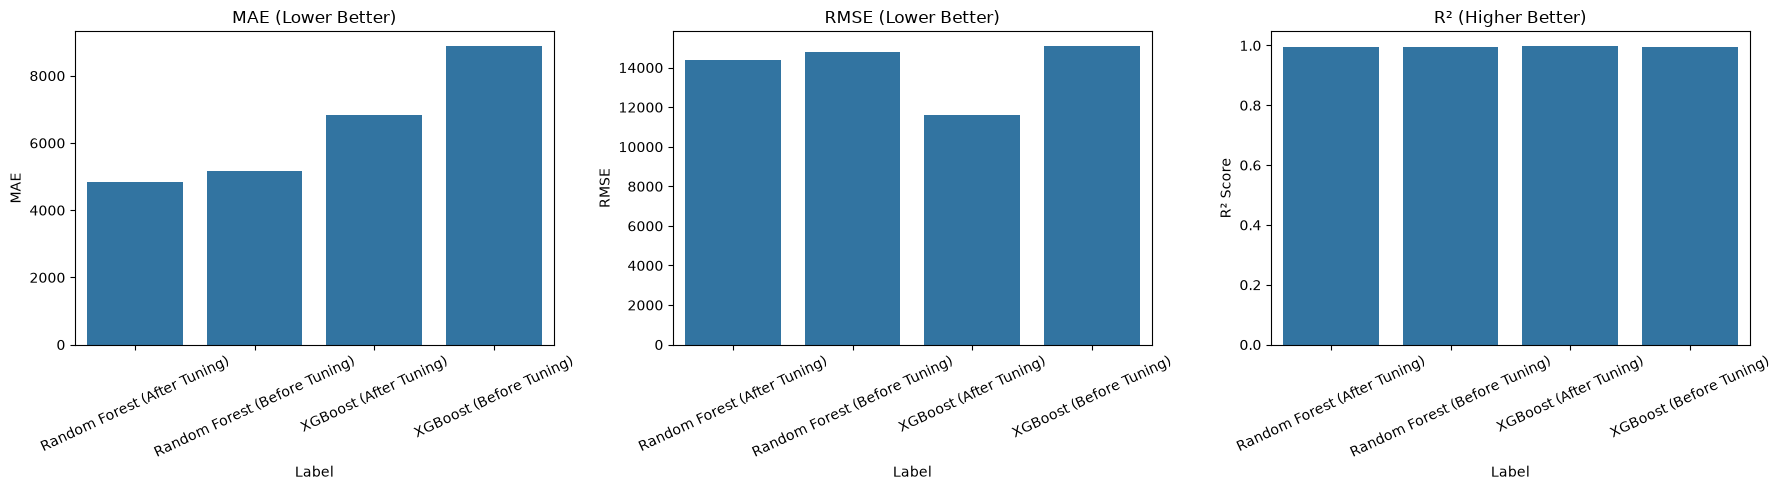

Best Model: XGBoost - After Tuning
MAE=6846.2576, RMSE=11589.2518, R²=0.9974


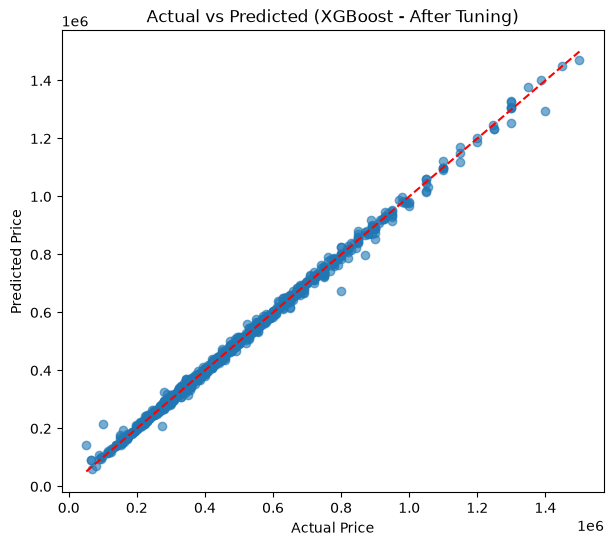


Interpretation:
Although Random Forest after tuning achieved the lowest MAE, XGBoost after tuning was selected as the best overall model because it achieved the lowest RMSE and the highest R² Score. This indicates that XGBoost after tuning produces fewer large prediction errors and explains a higher proportion of variance in property prices. Therefore, XGBoost after hyperparameter tuning is considered the most suitable model for the Smart Property Valuer system.


In [10]:
# Improvement table
rf_b = results_df[(results_df["Model"]=="Random Forest") & (results_df["Condition"]=="Before Tuning")].iloc[0]
rf_a = results_df[(results_df["Model"]=="Random Forest") & (results_df["Condition"]=="After Tuning")].iloc[0]
xgb_b = results_df[(results_df["Model"]=="XGBoost") & (results_df["Condition"]=="Before Tuning")].iloc[0]
xgb_a = results_df[(results_df["Model"]=="XGBoost") & (results_df["Condition"]=="After Tuning")].iloc[0]

def lower_better(before, after):
    return ((before - after) / before) * 100 if before != 0 else np.nan

def higher_better(before, after):
    return ((after - before) / abs(before)) * 100 if before != 0 else np.nan

improve_df = pd.DataFrame([
    {
        "Model Pair": "RF Before vs After",
        "MAE Improvement (%)": lower_better(rf_b["MAE"], rf_a["MAE"]),
        "RMSE Improvement (%)": lower_better(rf_b["RMSE"], rf_a["RMSE"]),
        "R² Improvement (%)": higher_better(rf_b["R² Score"], rf_a["R² Score"]),
    },
    {
        "Model Pair": "XGB Before vs After",
        "MAE Improvement (%)": lower_better(xgb_b["MAE"], xgb_a["MAE"]),
        "RMSE Improvement (%)": lower_better(xgb_b["RMSE"], xgb_a["RMSE"]),
        "R² Improvement (%)": higher_better(xgb_b["R² Score"], xgb_a["R² Score"]),
    },
])

display(improve_df.round(2))

# Metric bar charts
plot_df = results_df.copy()
plot_df["Label"] = plot_df["Model"] + " (" + plot_df["Condition"] + ")"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=plot_df, x="Label", y="MAE", ax=axes[0]); axes[0].set_title("MAE (Lower Better)"); axes[0].tick_params(axis='x', rotation=25)
sns.barplot(data=plot_df, x="Label", y="RMSE", ax=axes[1]); axes[1].set_title("RMSE (Lower Better)"); axes[1].tick_params(axis='x', rotation=25)
sns.barplot(data=plot_df, x="Label", y="R² Score", ax=axes[2]); axes[2].set_title("R² (Higher Better)"); axes[2].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

# BEST MODEL RULE:
# prioritize lowest RMSE, then highest R², then lowest MAE
best = results_df.sort_values(
    by=["RMSE", "R² Score", "MAE"],
    ascending=[True, False, True]
).iloc[0]

print("Best Model:", best["Model"], "-", best["Condition"])
print(f"MAE={best['MAE']:.4f}, RMSE={best['RMSE']:.4f}, R²={best['R² Score']:.4f}")

# Actual vs Predicted for best model
best_key = (best["Model"], best["Condition"])
best_pred = pred_store[best_key]

plt.figure(figsize=(7,6))
plt.scatter(y_test, best_pred, alpha=0.6)
min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted ({best['Model']} - {best['Condition']})")
plt.show()

# Final interpretation paragraph (as requested)
interpretation = (
    "Although Random Forest after tuning achieved the lowest MAE, "
    "XGBoost after tuning was selected as the best overall model because it achieved "
    "the lowest RMSE and the highest R² Score. This indicates that XGBoost after tuning "
    "produces fewer large prediction errors and explains a higher proportion of variance "
    "in property prices. Therefore, XGBoost after hyperparameter tuning is considered "
    "the most suitable model for the Smart Property Valuer system."
)

print("\nInterpretation:")
print(interpretation)